# Dialogue Act Features — Google Colab version

**Before running:**
1. Upload your `transcripts/final/` folder to Google Drive, e.g. `My Drive/affectai/transcripts/final/`
2. Set `TRANSCRIPT_DIR` and `OUT_DIR` in the Paths cell below
3. Runtime → Change runtime type → **T4 GPU**
4. Run All

Expected runtime: **~10 minutes** on T4 GPU.

In [19]:
# Install required packages (only needed once per Colab session)
!pip install -q transformers sentencepiece accelerate

In [22]:
# ── Paths ───────────────────────────────────────────────────────────────────
# Option A: files uploaded manually to /content/sample_data/ (no Drive needed)
TRANSCRIPT_DIR = '/content/sample_data'
OUT_DIR        = '/content'
# Option B: Drive → change to '/content/drive/MyDrive/your/path'
# ─────────────────────────────────────────────────────────────────────────────

import os
import pathlib
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Transcripts : {TRANSCRIPT_DIR}')
print(f'Output dir  : {OUT_DIR}')
print(f'Transcript .tsv files found: {len(list(pathlib.Path(TRANSCRIPT_DIR).glob("*.tsv")))}')

Transcripts : /content/sample_data
Output dir  : /content
Transcript .tsv files found: 37


In [23]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

WINDOW_S     = 30.0
PARTICIPANTS = ('P1', 'P2', 'P3', 'P4')

DA_LABELS = {
    'statement':    'expressing an opinion, asserting a fact, or sharing a personal view',
    'proposal':     'suggesting a new option, plan, or course of action for the group to consider',
    'agreement':    'endorsing, accepting, or affirming a prior idea or proposal from someone else',
    'disagreement': 'rejecting, opposing, or pushing back against an idea or proposal',
    'compromise':   'proposing to blend or combine competing options to reach common ground',
    'question':     'asking for information, clarification, or a decision from the group',
    'answer':       'responding directly to a question that was just asked',
    'backchannel':  'giving a brief acknowledgment like mm-hmm or yeah to signal attention without adding new content',
    'hedge':        'expressing uncertainty or tentatively softening a claim with words like maybe or probably',
    'decision':     'formally or informally moving the group toward a final decision or agreement',
    'offtask':      'making a joke, engaging in social talk, or saying something unrelated to the current task',
}

DA_SHORT      = list(DA_LABELS.keys())
DA_HYPOTHESES = list(DA_LABELS.values())
DA_PROB_COLS  = [f'da_{k}' for k in DA_SHORT]
HYP_TO_SHORT  = {v: k for k, v in DA_LABELS.items()}

print(f'{len(DA_LABELS)} dialogue act categories defined')

11 dialogue act categories defined


In [24]:
# Load transcripts
_FNAME_RE = re.compile(r'transcript_(grp[_-]?\d+)_(T\d+)_', re.IGNORECASE)

def _normalize_group_id(raw):
    digits = re.sub(r'^grp[_-]?', '', raw.lower())
    return f'grp-{int(digits):02d}'

all_events = []
for fpath in Path(TRANSCRIPT_DIR).glob('*.tsv'):
    m = _FNAME_RE.search(fpath.name)
    if not m:
        continue
    df = pd.read_csv(fpath, sep='\t')
    df['group_id'] = _normalize_group_id(m.group(1))
    df['task_id']  = m.group(2).upper()
    all_events.append(df)

events_df = pd.concat(all_events, ignore_index=True)

spk_events = events_df[
    (events_df['type'] == 'SPK') &
    (events_df['speaker'].isin(PARTICIPANTS)) &
    (events_df['text'].notna()) &
    (events_df['text'].str.strip() != '')
].copy()
spk_events['window_index'] = (spk_events['onset'] / WINDOW_S).apply(
    lambda x: int(x) if pd.notna(x) and x >= 0 else -1
)
spk_events = spk_events[spk_events['window_index'] >= 0].reset_index(drop=True)

print(f'Utterances to classify: {len(spk_events)}')

Utterances to classify: 3248


In [25]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f'Device: {"GPU " + torch.cuda.get_device_name(0) if device == 0 else "CPU (slow!)"}')

zsc = pipeline(
    'zero-shot-classification',
    model='MoritzLaurer/deberta-v3-base-zeroshot-v1',
    device=device,
)
print('Model ready.')

Device: GPU Tesla T4


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  369MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.65M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Model ready.


In [26]:
from tqdm.auto import tqdm

BATCH_SIZE = 64 if device == 0 else 16  # larger batches on GPU
utterances = spk_events['text'].tolist()
results = []

for i in tqdm(range(0, len(utterances), BATCH_SIZE), desc='Classifying'):
    batch = utterances[i : i + BATCH_SIZE]
    br = zsc(batch, candidate_labels=DA_HYPOTHESES, multi_label=False)
    if isinstance(br, dict):
        br = [br]
    results.extend(br)

print(f'Done. {len(results)} utterances classified.')

Classifying:   0%|          | 0/51 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done. 3248 utterances classified.


In [27]:
# Build utterance DA frame
utt_rows = []
for i, res in enumerate(results):
    row = {}
    for label, score in zip(res['labels'], res['scores']):
        row[f'da_{HYP_TO_SHORT[label]}'] = score
    row['da_dominant'] = HYP_TO_SHORT[res['labels'][0]]
    utt_rows.append(row)

utt_da_df = pd.DataFrame(utt_rows)
print('Dominant act distribution:')
print(utt_da_df['da_dominant'].value_counts())

Dominant act distribution:
da_dominant
hedge           2619
statement        251
proposal         128
compromise       114
decision          70
disagreement      26
agreement         20
question          11
backchannel        6
answer             3
Name: count, dtype: int64


In [28]:
# Aggregate per 30s window
spk_with_da = pd.concat(
    [spk_events[['group_id', 'task_id', 'window_index', 'speaker']].reset_index(drop=True),
     utt_da_df],
    axis=1
)

win_rows = []
for (grp, task, win), win_df in spk_with_da.groupby(['group_id', 'task_id', 'window_index']):
    row = {'group_id': grp, 'task_id': task, 'window_index': win,
           'da_n_utterances': len(win_df), 'da_n_speakers': win_df['speaker'].nunique()}
    for col in DA_PROB_COLS:
        row[col] = win_df[col].mean()
    row['da_dominant'] = win_df['da_dominant'].mode().iloc[0]
    win_rows.append(row)

da_df = pd.DataFrame(win_rows)

out_tsv = f'{OUT_DIR}/da_window_30s.tsv'
da_df.to_csv(out_tsv, sep='\t', index=False)
print(f'Saved {len(da_df)} windows → {out_tsv}')

Saved 597 windows → /content/da_window_30s.tsv


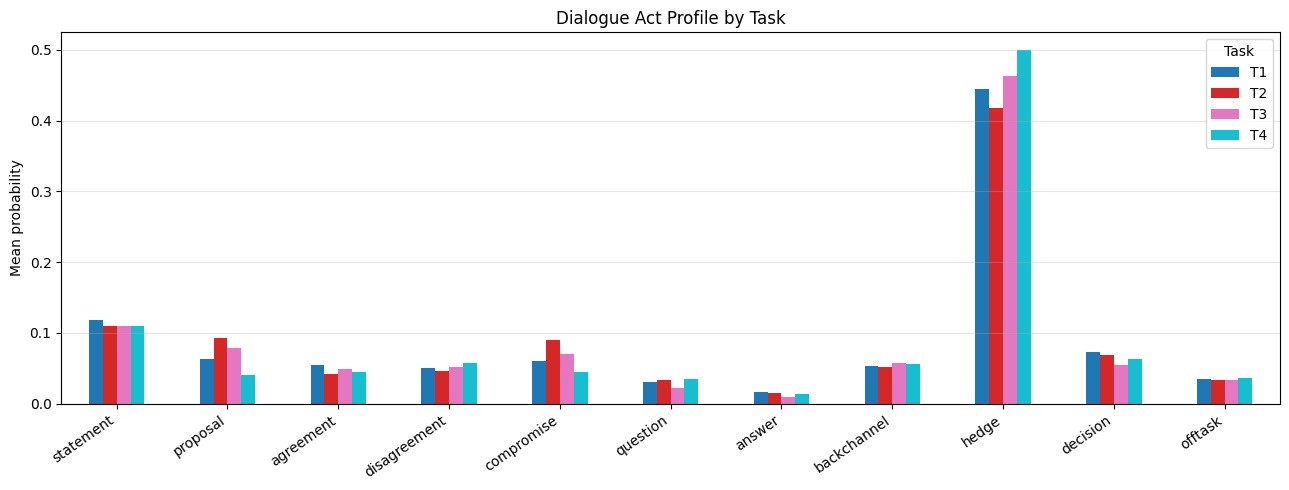

In [29]:
# DA profile by task
task_profile = da_df.groupby('task_id')[DA_PROB_COLS].mean()
fig, ax = plt.subplots(figsize=(13, 5))
task_profile.T.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_xticklabels([c.replace('da_', '') for c in DA_PROB_COLS], rotation=35, ha='right')
ax.set_title('Dialogue Act Profile by Task')
ax.set_ylabel('Mean probability')
ax.legend(title='Task')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(f'{OUT_DIR}/da_task_profile.png', dpi=150)
plt.show()

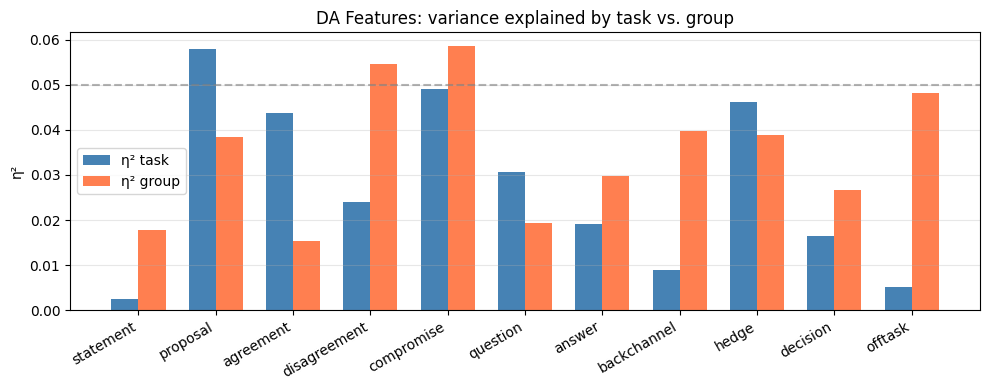

Mean η²_task  : 0.028
Mean η²_group : 0.035

Compare with BERT-UMAP: η²_task=0.36, η²_group=0.06
If DA η²_group >> 0.06: interaction structure carries more group signal than topic


In [30]:
# η² decomposition
eta_rows = []
for col in DA_PROB_COLS:
    vals = da_df[col].values
    grand_mean = vals.mean()
    ss_total = ((vals - grand_mean) ** 2).sum()
    if ss_total == 0:
        continue
    task_masks = [(da_df['task_id'] == t).values for t in da_df['task_id'].unique()]
    ss_task = sum((vals[m].mean() - grand_mean) ** 2 * m.sum() for m in task_masks)
    grp_masks = [(da_df['group_id'] == g).values for g in da_df['group_id'].unique()]
    ss_grp = sum((vals[m].mean() - grand_mean) ** 2 * m.sum() for m in grp_masks)
    eta_rows.append({'Feature': col.replace('da_', ''),
                     'η²_task': ss_task / ss_total, 'η²_group': ss_grp / ss_total})

eta_df = pd.DataFrame(eta_rows)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(eta_df))
w = 0.35
ax.bar(x - w/2, eta_df['η²_task'],  w, label='η² task',  color='steelblue')
ax.bar(x + w/2, eta_df['η²_group'], w, label='η² group', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(eta_df['Feature'], rotation=30, ha='right')
ax.axhline(0.05, color='grey', linestyle='--', alpha=0.6)
ax.set_title('DA Features: variance explained by task vs. group')
ax.set_ylabel('η²')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(f'{OUT_DIR}/da_eta2.png', dpi=150)
plt.show()

print(f"Mean η²_task  : {eta_df['η²_task'].mean():.3f}")
print(f"Mean η²_group : {eta_df['η²_group'].mean():.3f}")
print()
print('Compare with BERT-UMAP: η²_task=0.36, η²_group=0.06')
print('If DA η²_group >> 0.06: interaction structure carries more group signal than topic')